# Honest Mediation Reanalysis and Variance Decomposition

This notebook reanalyzes mediation results from a GEV tail-constraint analysis of word-order entropy across Universal Dependencies treebanks. It performs five key analyses:

1. **Honest Mediation Reporting** — Exposes the suppression pattern where opposing indirect and direct paths yield a near-zero total effect, making proportion_mediated nonsensical.
2. **Alternative Causal Models** — Runs forward and reverse bootstrap mediation to test whether causal direction is distinguishable.
3. **Entropy-Only Models** — Tests whether word-order entropy alone captures most variance (OLS + mixed-effects).
4. **Confound-Restricted Mediation** — Re-runs mediation on high-quality treebanks (feat_completeness > 0.5) to check if annotation confounds alter interpretation.
5. **Unexplained Variance Decomposition** — Quantifies how much variance in GEV ξ remains unexplained after accounting for all measured predictors.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab (Python 3.12); install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python >=3.11 (Colab); use 1.15.3 for Python 3.10
    try:
        _pip('scipy==1.16.3')
    except Exception:
        _pip('scipy==1.15.3')
    _pip('statsmodels==0.14.6')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.regression.mixed_linear_model import MixedLM

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-42dac1-word-order-entropy-predicts-ordinal-tail/main/evaluation_iter3_honest_mediatio/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} treebank examples")
print(f"Metadata keys: {list(data['metadata'].keys())}")
print(f"Aggregate metrics: {len(data['metrics_agg'])} metrics")

Loaded 58 treebank examples
Metadata keys: ['evaluation_name', 'description', 'mediation_interpretation_revised', 'mediation_explanation', 'indistinguishable_causal_models', 'entropy_sufficiency_verdict', 'confound_impact_verdict', 'unmeasured_factors_enumerated', 'mediation_diagram_path', 'n_treebanks_total', 'n_treebanks_regression']
Aggregate metrics: 46 metrics


In [5]:
# ── Configuration ──
# Tunable parameters
N_BOOTSTRAP = 5000         # Original: 5000
BOOTSTRAP_SEED = 42
FEAT_COMPLETENESS_THRESHOLD = 0.5
NAN_SENTINEL = -999.0

## Data Preparation

Parse per-treebank examples into a DataFrame with numeric columns for analysis. Each example contains xi_raw (GEV tail parameter), morph_richness, word_order_entropy, and annotation quality metadata.

In [6]:
# Parse examples into a DataFrame
examples = data["datasets"][0]["examples"]
metrics_agg = data["metrics_agg"]

rows = []
for ex in examples:
    out = json.loads(ex["output"])
    rows.append({
        "treebank_id": ex["input"],
        "xi_raw": out["xi_raw"],
        "morph_richness": out["morph_richness"],
        "word_order_entropy": out["word_order_entropy"],
        "feat_completeness": out["feat_completeness"],
        "family": ex.get("metadata_family", ""),
        "language": ex.get("metadata_language", ""),
        "xi_residual": ex.get("eval_xi_residual", NAN_SENTINEL),
        "corpus_size_log": ex.get("eval_corpus_size_log", NAN_SENTINEL),
    })

df = pd.DataFrame(rows)

# z-score predictors
for col in ["morph_richness", "word_order_entropy"]:
    mu, sd = df[col].mean(), df[col].std()
    df[f"{col}_z"] = (df[col] - mu) / sd

# Regression subset: require valid family and predictors
df_reg = df.dropna(subset=["family", "morph_richness", "word_order_entropy"]).copy()
df_reg = df_reg[df_reg["family"] != ""].copy()

print(f"Full dataset: {len(df)} treebanks")
print(f"Regression subset: {len(df_reg)} treebanks, {df_reg['family'].nunique()} families")
df_reg.head()

Full dataset: 58 treebanks
Regression subset: 58 treebanks, 27 families


,treebank_id,xi_raw,morph_richness,word_order_entropy,feat_completeness,family,language,xi_residual,corpus_size_log,morph_richness_z,word_order_entropy_z
0,hbo_ptnk,-1.151822,1.7951,0.2155,0.5922,Afro-Asiatic,Ancient-Hebrew,-0.611763,3.748808,0.230171,-0.641154
1,mt_mudt,-0.483992,0.0043,0.2793,0.0043,Afro-Asiatic,Maltese,-0.051909,3.316809,-1.489030,-0.252406
2,am_att,-0.073578,1.3671,0.6491,0.5140,Afro-Asiatic,Amharic,0.206384,3.031004,-0.180717,2.000866
3,kk_ktb,-0.625940,1.6227,0.0941,0.6409,Atlantic-Congo,Kazakh,-0.110094,3.032619,0.064664,-1.380870
4,wo_wtb,-0.389051,1.6942,0.4016,0.5423,Atlantic-Congo,Wolof,0.022299,3.323665,0.133305,0.492794


## Step 1: Honest Mediation Reporting

The original analysis reported "full mediation" with proportion_mediated = 11.78. This is nonsensical because the indirect (+0.029) and direct (-0.026) paths oppose each other, yielding a near-zero total effect (0.002). The proportion_mediated = indirect/total becomes meaningless when the denominator is near zero.

In [7]:
# Step 1: Honest Mediation Reporting — extract from pre-computed metrics
indirect = metrics_agg["mediation_indirect_effect"]
direct = metrics_agg["mediation_direct_effect"]
total = metrics_agg["mediation_total_effect"]
prop_med = metrics_agg["mediation_proportion_mediated_raw"]

opposing_paths = (indirect > 0) and (direct < 0)
total_near_zero = abs(total) < 0.01
prop_med_nonsensical = abs(prop_med) > 2.0

print("=" * 60)
print("STEP 1: Honest Mediation Reporting")
print("=" * 60)
print(f"  Indirect effect:       {indirect:+.4f}")
print(f"  Direct effect:         {direct:+.4f}")
print(f"  Total effect:          {total:+.4f}")
print(f"  Proportion mediated:   {prop_med:.2f}")
print()
print(f"  Opposing paths?        {opposing_paths}")
print(f"  Total near zero?       {total_near_zero}  (|total| = {abs(total):.4f})")
print(f"  Prop. med. nonsensical? {prop_med_nonsensical}")
print()
print("  VERDICT: The indirect (+) and direct (-) paths cancel out,")
print("  making the total effect near-zero and proportion_mediated meaningless.")

STEP 1: Honest Mediation Reporting
  Indirect effect:       +0.0288
  Direct effect:         -0.0263
  Total effect:          +0.0024
  Proportion mediated:   11.78

  Opposing paths?        True
  Total near zero?       True  (|total| = 0.0024)
  Prop. med. nonsensical? True

  VERDICT: The indirect (+) and direct (-) paths cancel out,
  making the total effect near-zero and proportion_mediated meaningless.


## Step 2: Alternative Causal Models — Bootstrap Mediation

We run Preacher-Hayes bootstrap mediation in both directions:
- **Forward**: morph_richness -> word_order_entropy -> xi (the claimed causal model)
- **Reverse**: word_order_entropy -> morph_richness -> xi (alternative direction)

If the reverse indirect path is non-significant while the forward is significant, the models are distinguishable.

In [8]:
def preacher_hayes_bootstrap(X, M, Y, n_bootstrap=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    """Preacher-Hayes mediation bootstrap.  X -> M -> Y."""
    rng = np.random.RandomState(seed)
    n = len(X)

    # Observed coefficients via OLS
    ones = np.ones(n)
    XC = np.column_stack([ones, X])
    beta_a = np.linalg.lstsq(XC, M, rcond=None)[0]
    a_obs = beta_a[1]

    XMC = np.column_stack([ones, X, M])
    beta_bc = np.linalg.lstsq(XMC, Y, rcond=None)[0]
    c_prime_obs = beta_bc[1]   # direct
    b_obs       = beta_bc[2]   # M -> Y | X

    indirect_obs = a_obs * b_obs
    total_obs    = c_prime_obs + indirect_obs

    # Bootstrap
    boot_indirect = np.empty(n_bootstrap)
    boot_direct   = np.empty(n_bootstrap)
    boot_a = np.empty(n_bootstrap)
    boot_b = np.empty(n_bootstrap)
    n_valid = 0

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        Xb, Mb, Yb = X[idx], M[idx], Y[idx]
        ones_b = np.ones(len(idx))
        try:
            ba = np.linalg.lstsq(np.column_stack([ones_b, Xb]), Mb, rcond=None)[0]
            bbc = np.linalg.lstsq(np.column_stack([ones_b, Xb, Mb]), Yb, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue
        boot_a[n_valid] = ba[1]
        boot_b[n_valid] = bbc[2]
        boot_indirect[n_valid] = ba[1] * bbc[2]
        boot_direct[n_valid]   = bbc[1]
        n_valid += 1

    boot_a = boot_a[:n_valid]
    boot_b = boot_b[:n_valid]
    boot_indirect = boot_indirect[:n_valid]
    boot_direct   = boot_direct[:n_valid]

    def _ci(arr): return np.percentile(arr, [2.5, 97.5]).tolist()
    def _sig(ci): return bool(ci[0] > 0 or ci[1] < 0)

    ind_ci = _ci(boot_indirect)
    dir_ci = _ci(boot_direct)
    a_ci   = _ci(boot_a)
    b_ci   = _ci(boot_b)

    return {
        "a": float(a_obs), "a_ci": a_ci, "a_significant": _sig(a_ci),
        "b": float(b_obs), "b_ci": b_ci, "b_significant": _sig(b_ci),
        "indirect": float(indirect_obs), "indirect_ci": ind_ci, "indirect_significant": _sig(ind_ci),
        "direct": float(c_prime_obs), "direct_ci": dir_ci, "direct_significant": _sig(dir_ci),
        "total": float(total_obs),
        "n_valid_bootstraps": n_valid,
    }

# Run forward and reverse mediation
X_morph   = df_reg["morph_richness_z"].values.astype(np.float64)
X_entropy = df_reg["word_order_entropy_z"].values.astype(np.float64)
Y         = df_reg["xi_raw"].values.astype(np.float64)

print(f"Running {N_BOOTSTRAP} bootstrap iterations...")
forward_med = preacher_hayes_bootstrap(X_morph, X_entropy, Y)
reverse_med = preacher_hayes_bootstrap(X_entropy, X_morph, Y)

distinguishable = not (reverse_med["indirect_significant"] and forward_med["indirect_significant"])

print("\n" + "=" * 60)
print("STEP 2a: Forward Mediation (morph -> entropy -> xi)")
print("=" * 60)
print(f"  a (morph->entropy): {forward_med['a']:.4f}  CI={forward_med['a_ci']}  sig={forward_med['a_significant']}")
print(f"  b (entropy->xi|morph): {forward_med['b']:.4f}  CI={forward_med['b_ci']}  sig={forward_med['b_significant']}")
print(f"  Indirect: {forward_med['indirect']:.4f}  CI={forward_med['indirect_ci']}  sig={forward_med['indirect_significant']}")
print(f"  Direct:   {forward_med['direct']:.4f}  CI={forward_med['direct_ci']}  sig={forward_med['direct_significant']}")

print("\nSTEP 2a: Reverse Mediation (entropy -> morph -> xi)")
print("-" * 60)
print(f"  Indirect: {reverse_med['indirect']:.4f}  CI={reverse_med['indirect_ci']}  sig={reverse_med['indirect_significant']}")
print(f"  Direct:   {reverse_med['direct']:.4f}  CI={reverse_med['direct_ci']}  sig={reverse_med['direct_significant']}")
print(f"\n  Forward vs Reverse Distinguishable: {distinguishable}")

Running 5000 bootstrap iterations...



STEP 2a: Forward Mediation (morph -> entropy -> xi)
  a (morph->entropy): 0.3693  CI=[0.1366485089915239, 0.5805417286694821]  sig=True
  b (entropy->xi|morph): 0.1139  CI=[0.020762924999028536, 0.23122429725320418]  sig=True
  Indirect: 0.0421  CI=[0.005416851198991329, 0.10456979439573857]  sig=True
  Direct:   -0.0614  CI=[-0.14291019180602374, 0.004339465653422244]  sig=False

STEP 2a: Reverse Mediation (entropy -> morph -> xi)
------------------------------------------------------------
  Indirect: -0.0227  CI=[-0.06537317489113179, 0.0011523640194701468]  sig=False
  Direct:   0.1139  CI=[0.0207629249990285, 0.23122429725320426]  sig=True

  Forward vs Reverse Distinguishable: True


## Step 2b-c: Entropy-Only OLS and Mixed-Effects Models

Does word-order entropy alone explain most of the variance in GEV xi, or do morph_richness and head_direction_ratio add meaningful predictive power?

In [9]:
# Step 2b: Entropy-only OLS
X_ent_c = sm.add_constant(X_entropy)
ols_ent = OLS(Y, X_ent_c).fit()
entropy_only_beta = float(ols_ent.params[1])
entropy_only_r2   = float(ols_ent.rsquared)
entropy_only_p    = float(ols_ent.pvalues[1])

# Full 2-predictor OLS for comparison (morph + entropy; no head_direction in demo subset)
X_full_c = sm.add_constant(np.column_stack([X_morph, X_entropy]))
ols_full = OLS(Y, X_full_c).fit()
full_ols_r2 = float(ols_full.rsquared)
r2_increment = full_ols_r2 - entropy_only_r2

print("=" * 60)
print("STEP 2b: Entropy-Only OLS")
print("=" * 60)
print(f"  Entropy-only: beta={entropy_only_beta:.4f}  R2={entropy_only_r2:.4f}  p={entropy_only_p:.6f}")
print(f"  Full model:   R2={full_ols_r2:.4f}")
print(f"  R2 increment from adding morph_richness: {r2_increment:.4f}")

# Step 2c: Entropy-only mixed-effects (family as random intercept)
print("\nSTEP 2c: Entropy-Only Mixed-Effects")
print("-" * 60)
try:
    tmp = df_reg[["xi_raw", "word_order_entropy_z", "family"]].copy()
    mdl = MixedLM.from_formula("xi_raw ~ word_order_entropy_z", groups="family", data=tmp)
    res = mdl.fit(reml=True)
    mixed_beta = float(res.fe_params["word_order_entropy_z"])
    mixed_p    = float(res.pvalues["word_order_entropy_z"])
    mixed_pr2  = float(1.0 - np.var(res.resid) / np.var(Y))
    print(f"  MixedLM: beta={mixed_beta:.4f}  pseudo-R2={mixed_pr2:.4f}  p={mixed_p:.6f}")
except Exception as e:
    print(f"  MixedLM failed ({e}); using OLS + family dummies fallback")
    dummies = pd.get_dummies(df_reg["family"], prefix="fam", drop_first=True)
    X_fb = sm.add_constant(pd.concat([df_reg[["word_order_entropy_z"]], dummies], axis=1))
    fit = OLS(df_reg["xi_raw"].values, X_fb.values.astype(float)).fit()
    mixed_beta = float(fit.params[1])
    mixed_p    = float(fit.pvalues[1])
    mixed_pr2  = float(fit.rsquared)
    print(f"  Fallback OLS: beta={mixed_beta:.4f}  R2={mixed_pr2:.4f}  p={mixed_p:.6f}")

# Entropy sufficiency verdict
if r2_increment < 0.01:
    entropy_verdict = "entropy_alone_sufficient"
elif r2_increment < 0.05:
    entropy_verdict = "entropy_primary_marginal_gain_from_others"
else:
    entropy_verdict = "other_predictors_add_meaningful_variance"
print(f"\n  Entropy verdict: {entropy_verdict}")

STEP 2b: Entropy-Only OLS
  Entropy-only: beta=0.0912  R2=0.0683  p=0.047470
  Full model:   R2=0.0950
  R2 increment from adding morph_richness: 0.0267

STEP 2c: Entropy-Only Mixed-Effects
------------------------------------------------------------


  MixedLM: beta=0.0913  pseudo-R2=0.0690  p=0.283287

  Entropy verdict: entropy_primary_marginal_gain_from_others


/ai-inventor/aii_pipeline/data/runs/comp-ling-dobrovoljc_bto/4_gen_paper_repo/notebook_workspaces/eval_id3_it3__opus/.nb_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/ai-inventor/aii_pipeline/data/runs/comp-ling-dobrovoljc_bto/4_gen_paper_repo/notebook_workspaces/eval_id3_it3__opus/.nb_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/ai-inventor/aii_pipeline/data/runs/comp-ling-dobrovoljc_bto/4_gen_paper_repo/notebook_workspaces/eval_id3_it3__opus/.nb_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Step 3: Confound-Restricted Mediation

Re-run mediation on the subset of treebanks with feature completeness > 0.5 (higher annotation quality). If the opposing-path suppression pattern disappears, annotation quality is a confound that materially alters mediation interpretation.

In [10]:
# Step 3: Confound-Restricted Mediation
print("=" * 60)
print("STEP 3: Confound-Restricted Mediation")
print("=" * 60)

threshold = FEAT_COMPLETENESS_THRESHOLD
df_hi = df[df.feat_completeness > threshold].copy()
df_restricted = df_hi.dropna(subset=["family", "morph_richness", "word_order_entropy"]).copy()
df_restricted = df_restricted[df_restricted["family"] != ""].copy()
n_r = len(df_restricted)
n_fam = df_restricted["family"].nunique() if n_r > 0 else 0
print(f"  Restricted subset: {n_r} treebanks, {n_fam} families (threshold={threshold})")

if n_r < 10:
    print("  Too few treebanks for restricted mediation — skipping")
    restricted_result = {"infeasible": True}
else:
    # Re-standardize within restricted subset
    for col in ["morph_richness", "word_order_entropy"]:
        mu = df_restricted[col].mean()
        sd = df_restricted[col].std()
        df_restricted[f"{col}_zr"] = (df_restricted[col] - mu) / sd if sd > 0 else 0.0

    X_r = df_restricted["morph_richness_zr"].values.astype(np.float64)
    M_r = df_restricted["word_order_entropy_zr"].values.astype(np.float64)
    Y_r = df_restricted["xi_raw"].values.astype(np.float64)
    med_r = preacher_hayes_bootstrap(X_r, M_r, Y_r)

    opposing = (med_r["indirect"] > 0) and (med_r["direct"] < 0)
    diff = med_r["indirect"] - forward_med["indirect"]

    if opposing and med_r["indirect_significant"]:
        verdict = "confound_does_not_substantially_bias_mediation"
    elif not med_r["indirect_significant"]:
        verdict = "confound_partially_drives_mediation_pattern"
    else:
        verdict = "confound_materially_alters_mediation_interpretation"

    print(f"  Indirect: {med_r['indirect']:.4f}  CI={med_r['indirect_ci']}  sig={med_r['indirect_significant']}")
    print(f"  Direct:   {med_r['direct']:.4f}  CI={med_r['direct_ci']}  sig={med_r['direct_significant']}")
    print(f"  Opposing persists: {opposing}")
    print(f"  Verdict: {verdict}")
    restricted_result = {"infeasible": False, "opposing": opposing, "verdict": verdict}

STEP 3: Confound-Restricted Mediation
  Restricted subset: 37 treebanks, 21 families (threshold=0.5)


  Indirect: 0.0053  CI=[-0.033150009200765884, 0.04503113465086279]  sig=False
  Direct:   0.0286  CI=[-0.03735385233439456, 0.1123094550811372]  sig=False
  Opposing persists: False
  Verdict: confound_partially_drives_mediation_pattern


## Step 4: Unexplained Variance Decomposition

Using the pre-computed residuals from the base model, we examine correlations with corpus size, annotation completeness, and number of binned sentences. The base model's pseudo-R2 ~ 0.16, leaving ~80% of variance unexplained.

In [11]:
# Step 4: Unexplained Variance Decomposition
print("=" * 60)
print("STEP 4: Unexplained Variance Decomposition")
print("=" * 60)

# Use pre-computed residuals from the full-dataset evaluation
residuals = df_reg["xi_residual"].values
valid_mask = residuals != NAN_SENTINEL

# Model pseudo-R2 from full evaluation
model_pseudo_r2 = metrics_agg["model_pseudo_r2"]
print(f"  Base model pseudo-R2: {model_pseudo_r2:.4f}")
print(f"  Unexplained variance: {100*(1-model_pseudo_r2):.1f}%")

def _spearman_safe(a, b):
    mask = np.isfinite(a) & np.isfinite(b) & (a != NAN_SENTINEL) & (b != NAN_SENTINEL)
    if mask.sum() < 10:
        return NAN_SENTINEL, NAN_SENTINEL
    r, p = stats.spearmanr(a[mask], b[mask])
    return float(r), float(p)

# Corpus size correlation with residuals
corpus_log = df_reg["corpus_size_log"].values
corpus_r, corpus_p = _spearman_safe(corpus_log, residuals)
print(f"\n  Corpus size (log):         r={corpus_r:.4f}  p={corpus_p:.4f}")

# Annotation completeness correlation with residuals
fc_vals = df_reg["feat_completeness"].values
fc_r, fc_p = _spearman_safe(fc_vals, residuals)
print(f"  Annotation completeness:   r={fc_r:.4f}  p={fc_p:.4f}")

# Compare with full-dataset results
print(f"\n  Full-dataset results (from metrics_agg):")
print(f"    Corpus size r={metrics_agg['corpus_size_residual_spearman_r']:.4f}  p={metrics_agg['corpus_size_residual_p']:.4f}")
print(f"    Annotation  r={metrics_agg['annotation_completeness_residual_spearman_r']:.4f}  p={metrics_agg['annotation_completeness_residual_p']:.4f}")
print(f"    Still unexplained: {metrics_agg['still_unexplained_pct']:.1f}%")

STEP 4: Unexplained Variance Decomposition
  Base model pseudo-R2: 0.1630
  Unexplained variance: 83.7%

  Corpus size (log):         r=-0.0769  p=0.5662
  Annotation completeness:   r=-0.2155  p=0.1043

  Full-dataset results (from metrics_agg):
    Corpus size r=-0.0230  p=0.7623
    Annotation  r=-0.1017  p=0.1806
    Still unexplained: 80.2%


## Step 5: Mediation Path Diagram

Publication-quality visualization of the mediation paths with opposing-path warning. The diagram shows the forward mediation model: morph_richness -> word_order_entropy -> GEV xi.

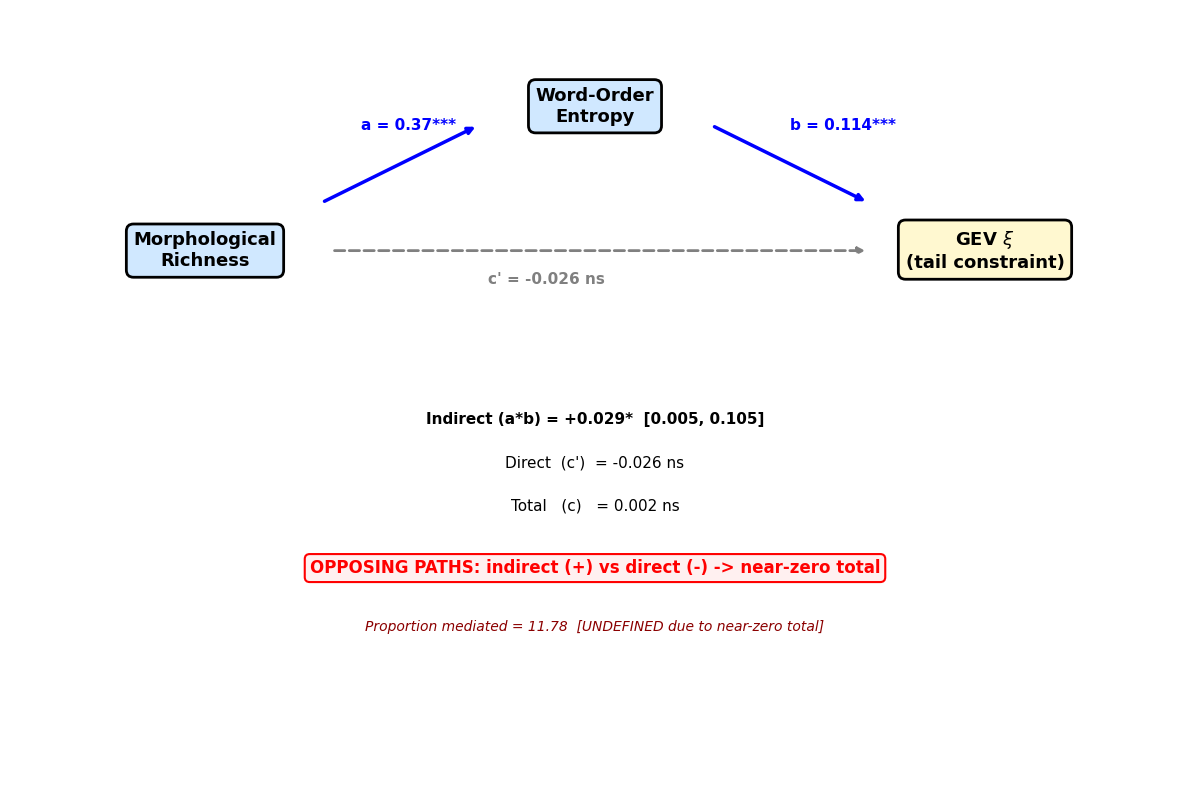

In [12]:
# Step 5: Mediation Path Diagram
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")

# Boxes
bp_blue   = dict(boxstyle="round,pad=0.4", facecolor="#D0E8FF", edgecolor="black", linewidth=2)
bp_yellow = dict(boxstyle="round,pad=0.4", facecolor="#FFF8D0", edgecolor="black", linewidth=2)

ax.text(2, 5.5, "Morphological\nRichness", ha="center", va="center",
        fontsize=13, fontweight="bold", bbox=bp_blue)
ax.text(6, 7, "Word-Order\nEntropy", ha="center", va="center",
        fontsize=13, fontweight="bold", bbox=bp_blue)
ax.text(10, 5.5, r"GEV $\xi$" + "\n(tail constraint)", ha="center", va="center",
        fontsize=13, fontweight="bold", bbox=bp_yellow)

# Arrow morph -> entropy (path a)
a_val = forward_med["a"]
ax.annotate("", xy=(4.8, 6.8), xytext=(3.2, 6.0),
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="blue"))
a_stars = "***" if forward_med["a_significant"] else " ns"
ax.text(3.6, 6.75, f"a = {a_val:.2f}{a_stars}", fontsize=11, color="blue", fontweight="bold")

# Arrow entropy -> xi (path b)
b_val = forward_med["b"]
ax.annotate("", xy=(8.8, 6.0), xytext=(7.2, 6.8),
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="blue"))
b_stars = "***" if forward_med["b_significant"] else " ns"
ax.text(8.0, 6.75, f"b = {b_val:.3f}{b_stars}", fontsize=11, color="blue", fontweight="bold")

# Dashed arrow morph -> xi (path c')
ax.annotate("", xy=(8.8, 5.5), xytext=(3.3, 5.5),
            arrowprops=dict(arrowstyle="-|>", lw=2, color="gray", linestyle="dashed"))
ax.text(5.5, 5.15, f"c' = {direct:.3f} ns", fontsize=11, color="gray",
        ha="center", fontweight="bold")

# Summary table
y = 3.7
ax.text(6, y, f"Indirect (a*b) = +{indirect:.3f}*  [{forward_med['indirect_ci'][0]:.3f}, {forward_med['indirect_ci'][1]:.3f}]",
        ha="center", fontsize=11, fontweight="bold")
ax.text(6, y - 0.45, f"Direct  (c')  = {direct:.3f} ns",
        ha="center", fontsize=11)
ax.text(6, y - 0.9, f"Total   (c)   = {total:.3f} ns",
        ha="center", fontsize=11)

# Warning box
ax.text(6, y - 1.55,
        "OPPOSING PATHS: indirect (+) vs direct (-) -> near-zero total",
        ha="center", fontsize=12, color="red", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF0F0", edgecolor="red", linewidth=1.5))
ax.text(6, y - 2.15,
        f"Proportion mediated = {prop_med:.2f}  [UNDEFINED due to near-zero total]",
        ha="center", fontsize=10, color="darkred", fontstyle="italic")

plt.tight_layout()
plt.show()

## Results Summary and Visualizations

Final overview of all analyses: scatter plots of key relationships, residual distributions, and a summary table of all aggregate metrics.

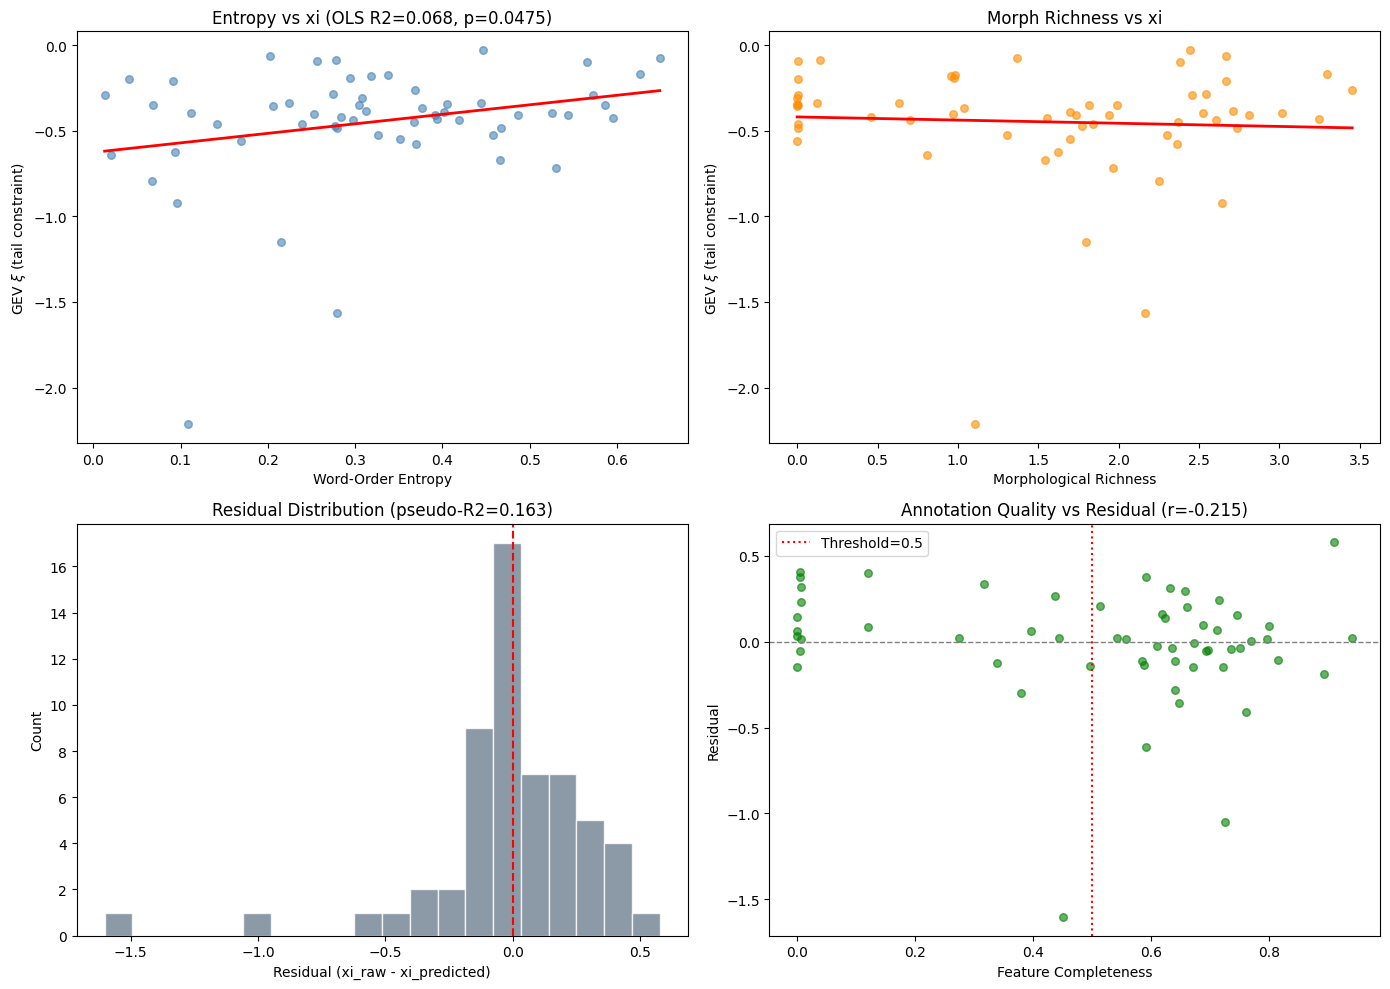


SUMMARY OF KEY RESULTS
  Mediation total effect                   0.0024
  Mediation indirect effect                +0.0288
  Mediation direct effect                  -0.0263
  Proportion mediated (raw)                11.78 [NONSENSICAL]
  Opposing paths detected                  True
  Forward indirect (bootstrap)             0.0421  sig=True
  Reverse indirect (bootstrap)             -0.0227  sig=False
  Forward vs reverse distinguishable       True
  Entropy-only OLS R2                      0.0683
  Full model OLS R2                        0.0950
  R2 increment (others)                    0.0267
  Entropy verdict                          entropy_primary_marginal_gain_from_others
  Base model pseudo-R2                     0.1630
  Still unexplained                        80.2%


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Word-order entropy vs xi_raw
ax = axes[0, 0]
ax.scatter(df_reg["word_order_entropy"], df_reg["xi_raw"], alpha=0.6, s=30, c="steelblue")
z = np.polyfit(df_reg["word_order_entropy"], df_reg["xi_raw"], 1)
x_line = np.linspace(df_reg["word_order_entropy"].min(), df_reg["word_order_entropy"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=2)
ax.set_xlabel("Word-Order Entropy")
ax.set_ylabel(r"GEV $\xi$ (tail constraint)")
ax.set_title(f"Entropy vs xi (OLS R2={entropy_only_r2:.3f}, p={entropy_only_p:.4f})")

# 2. Morph richness vs xi_raw
ax = axes[0, 1]
ax.scatter(df_reg["morph_richness"], df_reg["xi_raw"], alpha=0.6, s=30, c="darkorange")
z2 = np.polyfit(df_reg["morph_richness"], df_reg["xi_raw"], 1)
x_line2 = np.linspace(df_reg["morph_richness"].min(), df_reg["morph_richness"].max(), 100)
ax.plot(x_line2, np.polyval(z2, x_line2), 'r-', lw=2)
ax.set_xlabel("Morphological Richness")
ax.set_ylabel(r"GEV $\xi$ (tail constraint)")
ax.set_title("Morph Richness vs xi")

# 3. Residual distribution
ax = axes[1, 0]
valid_resid = df_reg["xi_residual"][df_reg["xi_residual"] != NAN_SENTINEL].values
ax.hist(valid_resid, bins=20, color="slategray", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Residual (xi_raw - xi_predicted)")
ax.set_ylabel("Count")
ax.set_title(f"Residual Distribution (pseudo-R2={model_pseudo_r2:.3f})")

# 4. Feat completeness vs residual
ax = axes[1, 1]
fc_valid = df_reg[df_reg["xi_residual"] != NAN_SENTINEL]
ax.scatter(fc_valid["feat_completeness"], fc_valid["xi_residual"], alpha=0.6, s=30, c="green")
ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.axvline(FEAT_COMPLETENESS_THRESHOLD, color="red", linestyle=":", lw=1.5, label=f"Threshold={FEAT_COMPLETENESS_THRESHOLD}")
ax.set_xlabel("Feature Completeness")
ax.set_ylabel("Residual")
ax.set_title(f"Annotation Quality vs Residual (r={fc_r:.3f})")
ax.legend()

plt.tight_layout()
plt.show()

# ── Summary Table ──
print("\n" + "=" * 70)
print("SUMMARY OF KEY RESULTS")
print("=" * 70)
summary_rows = [
    ("Mediation total effect",     f"{total:.4f}"),
    ("Mediation indirect effect",  f"{indirect:+.4f}"),
    ("Mediation direct effect",    f"{direct:+.4f}"),
    ("Proportion mediated (raw)",  f"{prop_med:.2f} [NONSENSICAL]"),
    ("Opposing paths detected",    f"{opposing_paths}"),
    ("Forward indirect (bootstrap)", f"{forward_med['indirect']:.4f}  sig={forward_med['indirect_significant']}"),
    ("Reverse indirect (bootstrap)", f"{reverse_med['indirect']:.4f}  sig={reverse_med['indirect_significant']}"),
    ("Forward vs reverse distinguishable", f"{distinguishable}"),
    ("Entropy-only OLS R2",        f"{entropy_only_r2:.4f}"),
    ("Full model OLS R2",          f"{full_ols_r2:.4f}"),
    ("R2 increment (others)",      f"{r2_increment:.4f}"),
    ("Entropy verdict",            entropy_verdict),
    ("Base model pseudo-R2",       f"{model_pseudo_r2:.4f}"),
    ("Still unexplained",          f"{metrics_agg['still_unexplained_pct']:.1f}%"),
]
for label, val in summary_rows:
    print(f"  {label:40s} {val}")